# TensorFlow Autoencoder simple example
- from [Intro to Autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder)

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score


/Users/ricky/VSCODE/timeseries_autoencoder/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import sys
import os

sys.path.append(os.path.join('..','src'))
from timeseries_autoencoder.utils import plot_reconstruction
from timeseries_autoencoder.data import get_tensorflow_ECG5000
from timeseries_autoencoder.autoencoders import FixedLengthFullyConnectedAutoEncoder

## Data download

In [3]:
train_data, test_data, train_labels, test_labels = get_tensorflow_ECG5000()

## Data normalization

In [4]:
min_val = np.min(train_data)
max_val = np.max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = np.float32(train_data)
test_data = np.float32(test_data)

## Nominal / Anomalous data separation

In [5]:
normal_train_data = train_data[train_labels == 0]
anomalous_train_data = train_data[train_labels == 1]

len(normal_train_data), len(anomalous_train_data)

(2359, 1639)

### Plot a normal vs anomalous ECG

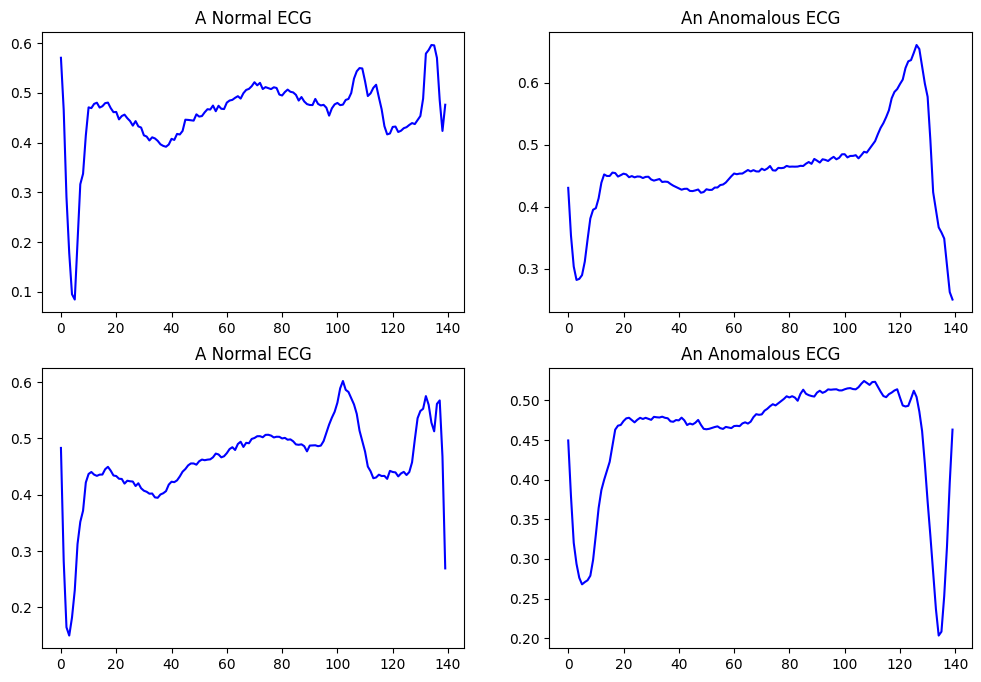

In [6]:
samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(normal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_train_data[s], axes[s][1]).set_title("An Anomalous ECG")


In [7]:
# split train set to get a validation
validation_fraction = 0.02

rng = np.random.default_rng(123)
index = np.arange(len(normal_train_data))

t = int(validation_fraction * len(normal_train_data))

validation_set = normal_train_data[:t]
train_set = normal_train_data[t:]

assert len(normal_train_data) == len(train_set) + len(validation_set)
print(f'train size: {len(train_set)} - validation size: {len(validation_set)}')

train size: 2312 - validation size: 47


In [8]:
autoencoder = FixedLengthFullyConnectedAutoEncoder()
autoencoder.compile(optimizer='adam', loss='mae')

history = autoencoder.fit(
    train_set,
    train_set,
    epochs=400,
    batch_size=256,
    validation_data=(validation_set, validation_set),
    shuffle=True
)

Epoch 1/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0568 - val_loss: 0.0526
Epoch 2/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0491 - val_loss: 0.0436
Epoch 3/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0405 - val_loss: 0.0352
Epoch 4/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0332 - val_loss: 0.0295
Epoch 5/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0286 - val_loss: 0.0263
Epoch 6/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0262 - val_loss: 0.0242
Epoch 7/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0244 - val_loss: 0.0225
Epoch 8/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0229 - val_loss: 0.0212
Epoch 9/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0217 - val_loss: 0.0203
Epoch 10/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0210 - val_loss: 0.0198
Epoch 11/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0205 - val_loss: 0.0194
Epoch 12/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

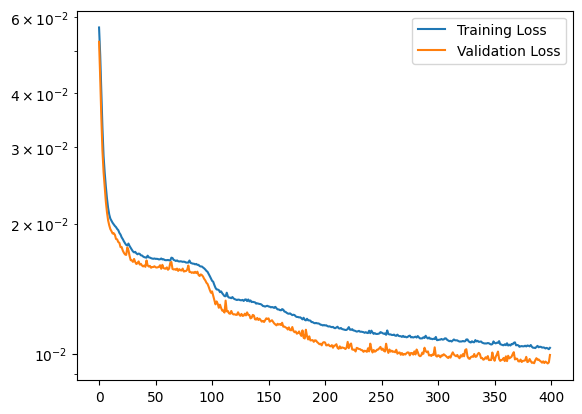

In [9]:
plt.semilogy(history.history["loss"], label="Training Loss")
plt.semilogy(history.history["val_loss"], label="Validation Loss")
plt.legend()

## Evaluate recontructions on Test data

In [10]:
normal_test_data = test_data[test_labels == 0]
anomalous_test_data = test_data[test_labels == 1]

normal_test_encoded = autoencoder.encoder(normal_test_data).numpy()
normal_test_reconstructed = autoencoder.decoder(normal_test_encoded).numpy()

anomalous_test_encoded = autoencoder.encoder(anomalous_test_data).numpy()
anomalous_test_reconstructed = autoencoder.decoder(anomalous_test_encoded).numpy()

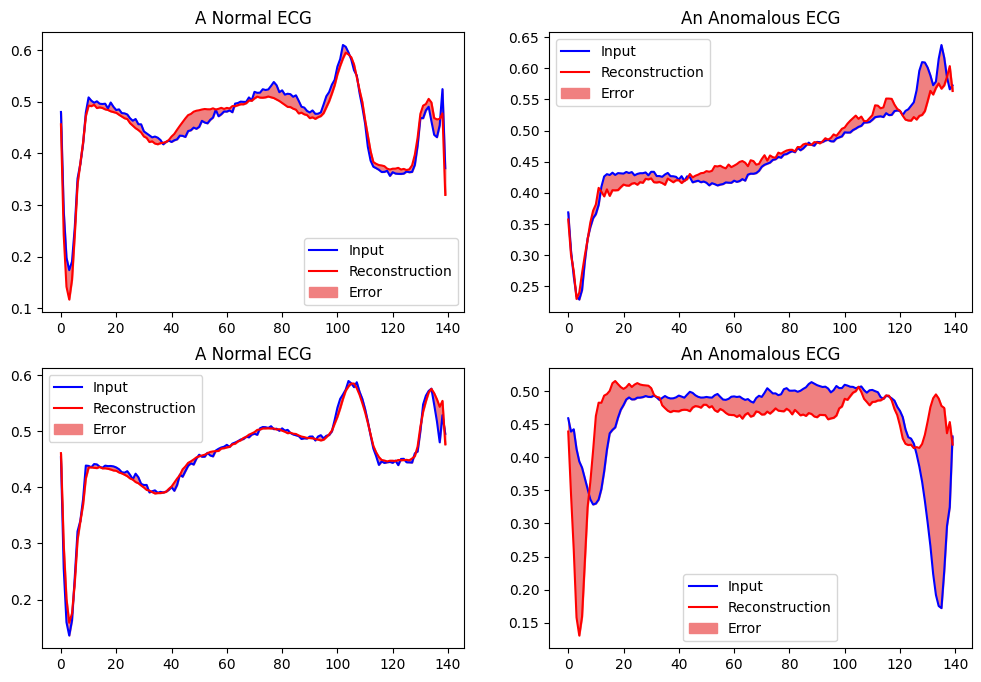

In [11]:

samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):

    plot_reconstruction(normal_test_data[s], axes[s][0], reconstruction=normal_test_reconstructed[s]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_test_data[s], axes[s][1], reconstruction=anomalous_test_reconstructed[s]).set_title("An Anomalous ECG")


## Find anomalies

In [12]:
normal_train_reconstructed = autoencoder.predict(normal_train_data)
normal_train_loss = tf.keras.losses.mae(normal_train_reconstructed, normal_train_data).numpy()

anomalous_train_reconstructed = autoencoder.predict(anomalous_train_data)
anomalous_train_loss = tf.keras.losses.mae(anomalous_train_reconstructed, anomalous_train_data).numpy()

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step


In [13]:
threshold = np.mean(normal_train_loss) + np.std(normal_train_loss)
print("Threshold: ", threshold)

Threshold:  0.015633466


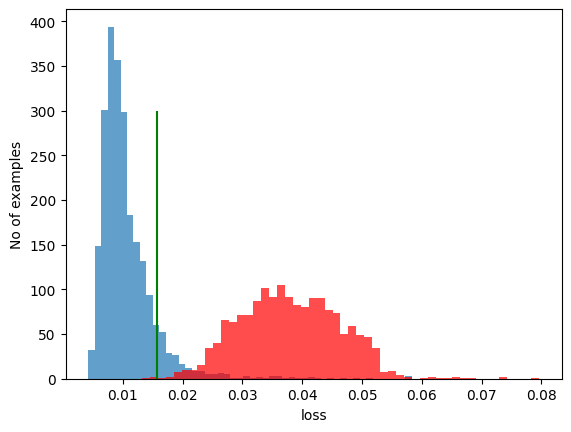

In [14]:
plt.hist(normal_train_loss, bins=50, alpha = 0.7)
plt.hist(anomalous_train_loss, bins=50, color='red', alpha=0.7)
plt.xlabel("loss")
plt.ylabel("No of examples")
plt.vlines([threshold], 0, 300, colors=['green'])

In [15]:
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.greater(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

In [16]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.95
Precision = 0.9012345679012346
Recall = 0.9954545454545455


In [17]:
df = pd.DataFrame(
    data = {
        'ground_truth': test_labels,
        'predicted': preds
    }
)

df

,ground_truth,predicted
0,0,False
1,1,True
2,0,False
3,0,True
4,1,True
...,...,...
995,1,True
996,0,False
997,0,True
998,0,False


In [18]:
errors = df[df['ground_truth'] !=  df['predicted']]
corrects = df[df['ground_truth'] ==  df['predicted']]

In [19]:
# it seems that I need to find Flse for positives and True for negatives
false_positives = errors[errors['predicted'] == True]
false_negatives = errors[errors['predicted'] == False]

true_positives = corrects[corrects['ground_truth'] == True]
true_negatives = corrects[corrects['ground_truth'] == False]

In [20]:
n_true_positives = len(true_positives)
n_true_negatives = len(true_negatives)
n_false_positives = len(false_positives)
n_false_negatives = len(false_negatives)

print(f'accuracy: {(n_true_positives + n_true_negatives) / (n_true_positives + n_true_negatives + n_false_positives + n_false_negatives)}')
print(f'precision: {(n_true_positives) / (n_true_positives + n_false_positives)}')
print(f'recall: {(n_true_positives) / (n_true_positives + n_false_negatives)}')

accuracy: 0.95
precision: 0.9012345679012346
recall: 0.9954545454545455


## Examining false positives

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Threshold:  0.015633466
false_positives_loss:  [0.01585356 0.03173137 0.02111007 0.01708548 0.01584939 0.01866476
 0.01717633 0.03204058 0.02011107 0.01760383 0.0201372  0.01722101
 0.02145611 0.01584706 0.01584611 0.02701878 0.01580373 0.01933681
 0.01680204 0.02002191 0.01773716 0.03649269 0.01662003 0.02260805
 0.02278068 0.01740773 0.01995817 0.01675584 0.02373642 0.02020817
 0.0191032  0.01943816 0.02274996 0.01761876 0.01951824 0.01884363
 0.0197005  0.02848813 0.03023167 0.01602575 0.02057998 0.0193205
 0.01584044 0.01754746 0.01579522 0.02060497 0.02399169 0.01696871]


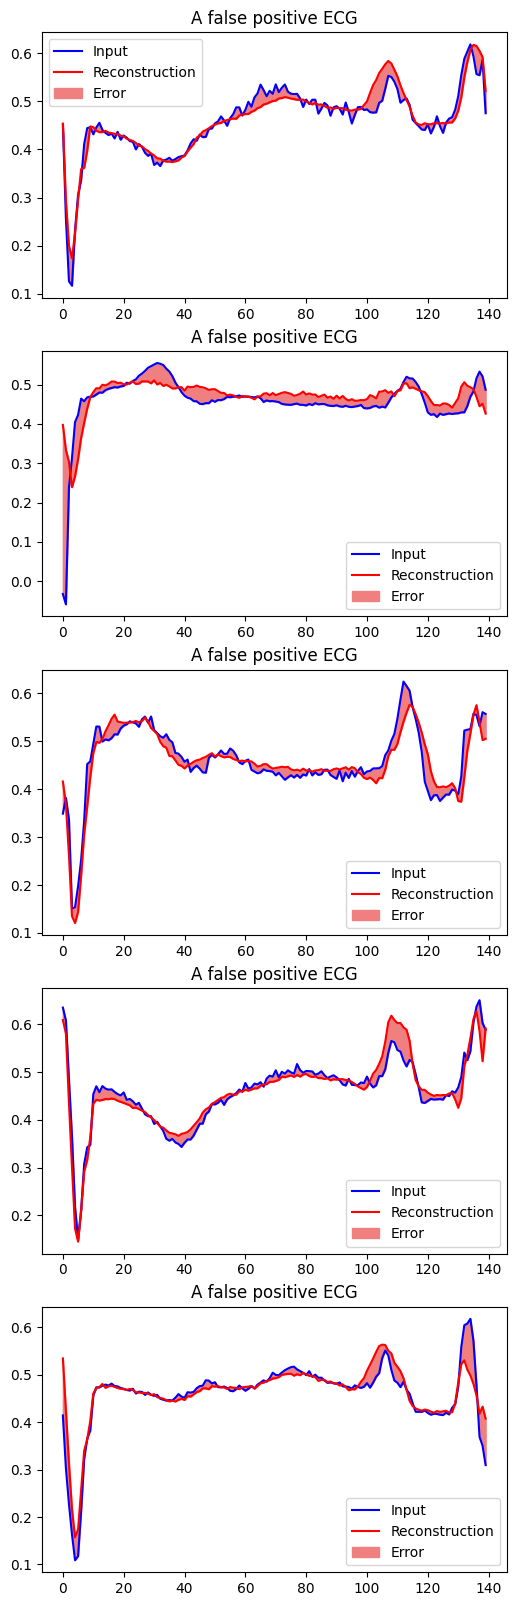

In [21]:
fp_idx = false_positives.index.values


if fp_idx.size > 0:
    false_positives_data = test_data[fp_idx]
    false_positives_reconstructed = autoencoder.predict(false_positives_data)
    false_positives_loss = tf.keras.losses.mae(false_positives_reconstructed, false_positives_data).numpy()
    
    print("Threshold: ", threshold)
    print("false_positives_loss: ", false_positives_loss)
    
    samples = np.min([5, len(fp_idx)])
    fig, axes = plt.subplots(samples, 1, figsize=(6,4*samples), squeeze = False)
    
    for s in range(samples):
        plot_reconstruction(false_positives_data[s], axes[s][0], reconstruction=false_positives_reconstructed[s]).set_title("A false positive ECG")


## Examining false negatives

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Threshold:  0.015633466
false_negatives_loss:  [0.00699977 0.0082635 ]


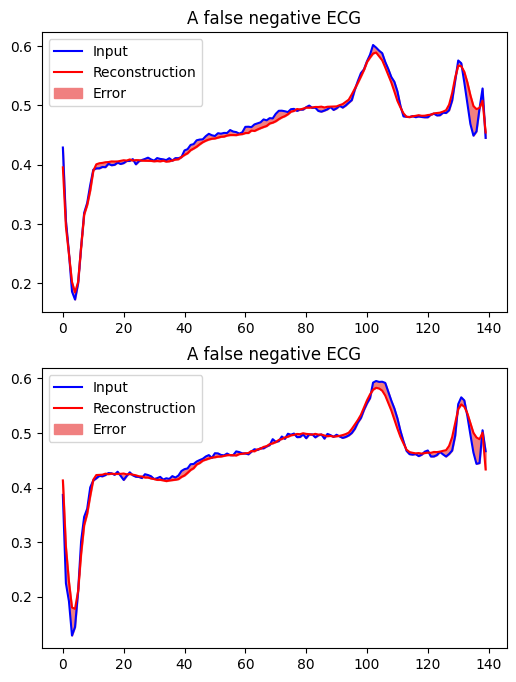

In [22]:
fn_idx = false_negatives.index.values

if fn_idx.size > 0:
    false_negatives_data = test_data[fn_idx]
    false_negatives_reconstructed = autoencoder.predict(false_negatives_data)
    false_negatives_loss = tf.keras.losses.mae(false_negatives_reconstructed, false_negatives_data).numpy()

    print("Threshold: ", threshold)
    print("false_negatives_loss: ", false_negatives_loss)

    samples = np.min([5, len(fn_idx)])
    fig, axes = plt.subplots(samples, 1, figsize=(6,4*samples), squeeze = False)

    for s in range(samples):
        plot_reconstruction(false_negatives_data[s], axes[s][0], reconstruction=false_negatives_reconstructed[s]).set_title("A false negative ECG")
